In [1]:
%cd /home/maia-user/NeuroCBIR/
!ls

/home/maia-user/NeuroCBIR
data  main.ipynb  model  preprocessing	README.md


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import torch
import torch.nn as nn
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from IPython.display import clear_output

seed = 42

In [ ]:
# # Loading MRI  paths
# from preprocessing.nii2npy import convert_nii_to_npy
# from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label

# dataset_path = "/home/maia-user/Dataset/OASIS3/"
# file_paths, file_names = list_files_with_extension(dataset_path, extension="align_norm+cropped.nii.gz")

# raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
# raw_image_ids = np.array([file_path.split('/')[1] for file_path in file_paths])  # e.g., "OAS30001"

# # Optional PE
# # pos_en = positionalencoding2d(4, 128, 128).detach().cpu().numpy()
# pos_en = None

# convert_nii_to_npy(raw_image_paths, raw_image_ids, output_dir="/home/maia-user/Dataset/OASIS3_NPY/", pe=pos_en)

(160, 176, 208) 1.0 0.0


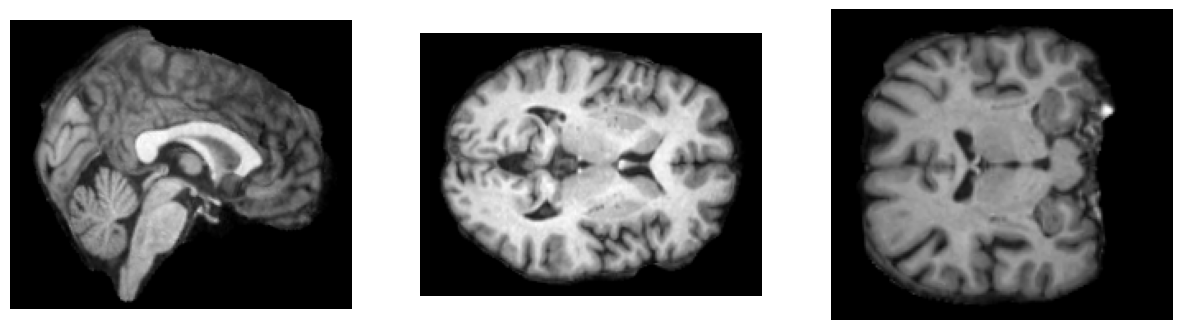

In [4]:
# Load NIfTI file
nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_norm+cropped.nii.gz")
mri_data = nifti_img.get_fdata()

# Show a single slice (assuming 3D MRI data)
print(mri_data.shape, np.max(mri_data), np.min(mri_data))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mri_data[mri_data.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_data[:, mri_data.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_data[:, :, mri_data.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()


In [ ]:
# # Load NIfTI file
# nifti_img = nib.load(r"/home/maia-user/Dataset/ADNI/T1w/00a0cea4-62f5-4aa9-96f0-f0b9f99c9919/crop_rescaled_align_norm.nii.gz")
# mri_data = nifti_img.get_fdata()

# # Show a single slice (assuming 3D MRI data)
# print(mri_data.shape, np.max(mri_data), np.min(mri_data))
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# axes[0].imshow(mri_data[mri_data.shape[0] // 2, : ,:], cmap="gray")
# axes[0].axis("off")
# axes[1].imshow(mri_data[:, mri_data.shape[1] // 2, :], cmap="gray")
# axes[1].axis("off")
# axes[2].imshow(mri_data[:, :, mri_data.shape[2] // 2], cmap="gray")
# axes[2].axis("off")
# plt.show()

In [6]:
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label

# Loading MRI  paths
dataset_path = r"/home/maia-user/Dataset/OASIS3_NPY/"
file_paths, file_names = list_files_with_extension(dataset_path, extension=".npy")
raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('.')[0] for file_path in file_names])

/home/maia-user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Load file with labels
labels_path = r"/home/maia-user/Dataset/OASIS3/OASIS3_UDSb4_cdr.xlsx"
labels_df = pd.read_excel(labels_path, sheet_name= 'Labels')

# Some recordings might be removed, i.e. nan labels
raw_labels = np.array([get_label(image_id, labels_df) for image_id in raw_image_ids]).astype('float32')
raw_ages = np.array([get_label(image_id, labels_df, column='age_at_visit') for image_id in raw_image_ids]).astype('float32')
raw_ids = np.array([get_label(image_id, labels_df, column='OASISID') for image_id in raw_image_ids])

In [8]:
# Filtering out undesired cases
labels = raw_labels[~np.isnan(raw_labels)]
image_paths = raw_image_paths[~np.isnan(raw_labels)]
ages = raw_ages[~np.isnan(raw_labels)]
ids = raw_ids[~np.isnan(raw_labels)]

print(raw_labels.shape, labels.shape)

(2681,) (2680,)


In [9]:
from preprocessing.split_dataset import stratified_patient_split

# Longitudinal splitting dataset into training and testing sets
train_set, val_set, test_set = stratified_patient_split(image_paths, labels, ages, ids)

# Print dataset sizes
print(f"Training samples: {len(train_set['image_paths'])} - IR: {np.sum(train_set['labels'])/len(train_set['image_paths']):.2f}")
print(f"Validation samples: {len(val_set['image_paths'])} - IR: {np.sum(val_set['labels'])/len(val_set['image_paths']):.2f}")
print(f"Testing samples: {len(test_set['image_paths'])} - IR: {np.sum(test_set['labels'])/len(val_set['image_paths']):.2f}")

Training samples: 1852 - IR: 0.20
Validation samples: 372 - IR: 0.21
Testing samples: 456 - IR: 0.26


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [11]:
from preprocessing.load_dataset import StratifiedBatchSampler
import torchio as tio

minibatch_size = 8  # Make sure this is even!

augmentation_transforms = tio.Compose([
                                        # tio.RandomAffine(
                                        #     scales=(0.9, 1.05),        # Random scaling
                                        #     degrees=5,               # Random rotation in degrees
                                        #     translation=5            # Random translation in mm
                                        # ),
                                        tio.RandomNoise(mean=0.0, std=0.02),
                                        # tio.RandomFlip(axes=('LR',)),  # Random left-right flip
                                    ])

# Preparing the dataset to feed the network
train_dataset = BrainMRIDataset(train_set['image_paths'], train_set['ages'], train_set['labels'], 
                                transform=augmentation_transforms, transform_age=3)
train_sampler = StratifiedBatchSampler(train_dataset, minibatch_size)
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=1, pin_memory=True)

val_dataset = BrainMRIDataset(val_set['image_paths'], val_set['ages'], val_set['labels'])
val_sampler = StratifiedBatchSampler(val_dataset, 2)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=1)

test_dataset = BrainMRIDataset(test_set['image_paths'], test_set['ages'], test_set['labels'])
test_sampler = StratifiedBatchSampler(test_dataset, 2)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, num_workers=1)

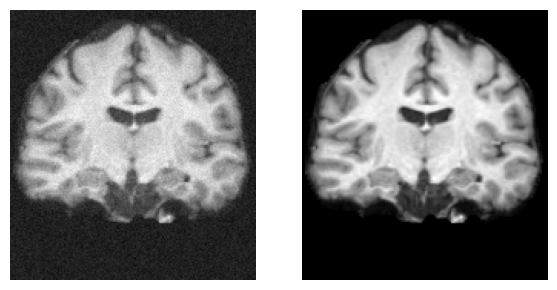

In [12]:
# Fetch one sample from the dataset
sample_1, sample_2 = train_dataset[0], train_dataset[-55]  # Get the first case

# Extract MRI image and mask
mri_image_1 = sample_1["input"].squeeze().detach().cpu().numpy() # Remove channel dimension
mri_image_2 = sample_1["output"].squeeze().detach().cpu().numpy() # Remove channel dimension


# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Load the image
axes[0].imshow(mri_image_1[:, :,  mri_image_1.shape[-1] // 2].T, cmap="gray")
axes[0].axis('off')

axes[1].imshow(mri_image_2[:, :, mri_image_2.shape[-1] // 2].T, cmap="gray")
axes[1].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
# Display the plotS
plt.show()

In [13]:
import torch
from model.autoencoder import Conv3DAutoencoder
from torchsummary import summary

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Input size: [160, 176, 208]
input_size = list(mri_image_1.shape)

# Initialize model and move it to the correct device
autoencoder = Conv3DAutoencoder().to(device)
pretrained_param = torch.load('./data/pretrained_models/autoencoder_3d.pth')
# autoencoder.load_state_dict(pretrained_param)

# Keep only matching keys (ignore fully connected layers)
pretrained_dict = pretrained_param
new_model_dict = autoencoder.state_dict()
pretrained_dict = {k: v for k, v in pretrained_dict.items() if k in new_model_dict}
# Load weights into the new model
new_model_dict.update(pretrained_dict)
autoencoder.load_state_dict(new_model_dict)

# Run summary — torchsummary will match the device of the model
summary(autoencoder, (1, *input_size))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv3d-1      [-1, 16, 80, 88, 104]             448
    InstanceNorm3d-2      [-1, 16, 80, 88, 104]               0
              ReLU-3      [-1, 16, 80, 88, 104]               0
         Dropout3d-4      [-1, 16, 80, 88, 104]               0
            Conv3d-5       [-1, 32, 40, 44, 52]          13,856
    InstanceNorm3d-6       [-1, 32, 40, 44, 52]               0
              ReLU-7       [-1, 32, 40, 44, 52]               0
         Dropout3d-8       [-1, 32, 40, 44, 52]               0
            Conv3d-9       [-1, 32, 20, 22, 26]          27,680
   InstanceNorm3d-10       [-1, 32, 20, 22, 26]               0
             ReLU-11       [-1, 32, 20, 22, 26]               0
           Conv3d-12       [-1, 64, 10, 11, 13]          55,360
   InstanceNorm3d-13       [-1, 64, 10, 11, 13]               0
             ReLU-14       [-1, 64, 10,

In [14]:
import torch.nn.functional as F

def gradient_loss(x, x_recon):
    dx = torch.abs(x[:, :, 1:, :, :] - x[:, :, :-1, :, :])
    dy = torch.abs(x[:, :, :, 1:, :] - x[:, :, :, :-1, :])
    dz = torch.abs(x[:, :, :, :, 1:] - x[:, :, :, :, :-1])

    dxr = torch.abs(x_recon[:, :, 1:, :, :] - x_recon[:, :, :-1, :, :])
    dyr = torch.abs(x_recon[:, :, :, 1:, :] - x_recon[:, :, :, :-1, :])
    dzr = torch.abs(x_recon[:, :, :, :, 1:] - x_recon[:, :, :, :, :-1])

    return F.l1_loss(dx, dxr) + F.l1_loss(dy, dyr) + F.l1_loss(dz, dzr)


In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np



def train(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader, desc="Training"):
        images_input = batch['input'].to(device, dtype=torch.float32)
        images_gt = batch['output'].to(device, dtype=torch.float32)
        # ages = batch['age'].to(device, dtype=torch.float32)
        # targets = batch['label'].to(device, dtype=torch.float32)  # shape: (B, 1) or (B,)
        _, images_out = model(images_input)
        loss = criterion(images_out, images_gt) #+ gradient_loss(images_out, images_gt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Config
# batch_size = 4
lr = 1e-3
epochs = 50000

# model = Conv3DAutoencoder().to(device)
# dataset = DummyMRI3DDataset(n_samples=200)
# loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

optimizer = optim.Adam(autoencoder.parameters(), lr=lr)
criterion = nn.MSELoss()

for epoch in range(epochs):
    loss = train(autoencoder, train_loader, optimizer, criterion, device)
    print(f"[Epoch {epoch+1}] Loss: {loss:.4f}")

    torch.save(autoencoder.state_dict(), "./data/pretrained_models/autoencoder_3d.pth")




Training:  10%|█         | 37/369 [02:49<21:31,  3.89s/it] 

In [15]:
dataset = BrainMRIDataset(image_paths, ages, labels)

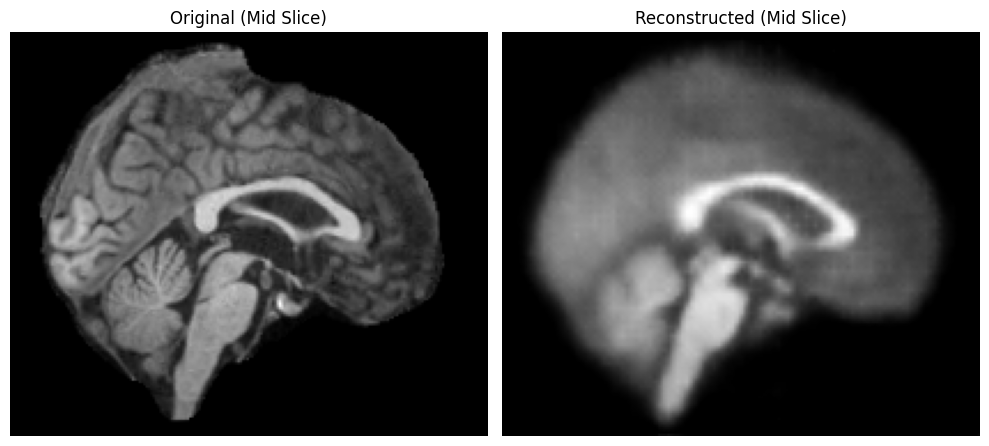

In [16]:
import torch
import matplotlib.pyplot as plt
import numpy as np

sample_1 = dataset[3] # Get the first case


# Instantiate and set to eval mode
autoencoder.eval()

# Dummy 3D input (or replace with your real data)


# Pass through model
with torch.no_grad():
    input_img = sample_1["input"].unsqueeze(0).to(device, dtype=torch.float32)
    z, reconstructed = autoencoder(input_img)

# Detach and convert to NumPy
original_np = input_img.squeeze([0,1]).cpu().detach().numpy()
reconstructed_np = reconstructed.squeeze().cpu().numpy()

# Select a middle slice in the axial (depth) axis
mid_slice = original_np.shape[0] // 2
orig_slice = original_np[mid_slice, :, :]
recon_slice = reconstructed_np[mid_slice, :, :]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(orig_slice, cmap='gray')
axes[0].set_title('Original (Mid Slice)')
axes[0].axis('off')

axes[1].imshow(recon_slice, cmap='gray')
axes[1].set_title('Reconstructed (Mid Slice)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [14]:
import psutil
import os

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

def extract_whole_image_features(autoencoder, dataset, device="cuda"):
    autoencoder.to(device)
    autoencoder.eval()
    features = []
    metadata = []

    for idx in tqdm(range(len(dataset)), desc="Extracting features"):
        sample = dataset[idx]
        img = sample["input"].unsqueeze(0).to(device, dtype=torch.float32)  # Add batch dim
        
        with torch.no_grad():
            z, _ = autoencoder(img)
        
        features.append(z.view(-1).cpu().numpy())
        metadata.append({
            "index": idx,
            "label": sample["label"].item(),
            "age": sample["age"].item(),
        })
        
    return np.array(features), metadata


t = -1
dataset = BrainMRIDataset(image_paths[0:t], ages[0:t], labels[0:t])
features, metadata = extract_whole_image_features(autoencoder, dataset, device="cpu")

np.save("./data/global_features.npy", features)
np.save("./data/global_metadata.npy", metadata)



Extracting features:  66%|██████▌   | 1764/2679 [34:11<14:25,  1.06it/s] 

In [20]:
features.shape

(2679, 1024)

In [34]:
import gc

process = psutil.Process(os.getpid())
print(f"RAM used: {process.memory_info().rss / 1024 ** 2:.2f} MB")
gc.collect()
torch.cuda.empty_cache()
process = psutil.Process(os.getpid())
print(f"RAM used: {process.memory_info().rss / 1024 ** 2:.2f} MB")

RAM used: 4235.94 MB
RAM used: 4235.94 MB
